In [11]:
# import necessary packages

# CIL imports
from cil.framework import ImageGeometry, AcquisitionGeometry, BlockDataContainer, ImageData

# From cil.plugins import TomoPhantom
from phantominator import shepp_logan

from cil.optimisation.functions import LeastSquares, BlockFunction, L2NormSquared

# For display
from cil.utilities.display import show2D, show1D, show_geometry

# ASTRA imports
from cil.plugins.astra.operators import ProjectionOperator

from cil.optimisation.algorithms import CGLS, GD

# External imports
import numpy as np
import matplotlib.pyplot as plt
import logging

from cil.optimisation.operators import BlockOperator, DiagonalOperator, GradientOperator, \
                                        CompositionOperator, ZeroOperator

In [12]:
# setting pixels and angles
n_pixels = 265
n_angles = 50

## Setting up CT problem

In [13]:
# Set logging level for CIL processors:
logging.basicConfig(level=logging.WARNING)
cil_log_level = logging.getLogger('cil.processors')
cil_log_level.setLevel(logging.INFO)

# Setting background defaults
cmap = "rainbow"
device = "cpu"

In [14]:
def get_A(n_angles, n_pixels):

    # Angles
    angles = np.linspace(0, 180, n_angles, endpoint=False, dtype=np.float32)

    # Setup acquisition geometry

    # Note that if number of pixels and number of angels are equal, 
    # the matrix is square and an exact solution can be found, 
    # then there is a sufficient number of pojections
    ag = AcquisitionGeometry.create_Parallel2D()\
                                .set_angles(angles)\
                                .set_panel(n_pixels, pixel_size=1/n_pixels)

    # Setup image geometry
    ig = ImageGeometry(voxel_num_x=n_pixels, 
                    voxel_num_y=n_pixels, 
                    voxel_size_x=1/n_pixels, 
                    voxel_size_y=1/n_pixels)
    
    A = ProjectionOperator(ig, ag, device='cpu')

    # Get phantom
    phantom = ImageData(np.flip(shepp_logan(n_pixels)), geometry = ig)

    # Create an acquisition data (numerically)
    sino = A.direct(phantom)

    return A, sino, ig, ag, phantom


def add_poss_noise(background_counts, n_angles, n_pixels):
    A, sino, ig, ag, phantom = get_A(n_angles, n_pixels)

    # adding noise to the sinogram

    # Convert the simulated absorption sinogram to transmission values using Lambert-Beer. 
    counts_poss = background_counts * np.exp(-sino.as_array())

    # Use as a mean for Poisson data generation.
    noisy_counts_poss = np.random.poisson(counts_poss)
    nonzero = noisy_counts_poss > 0

    # Convert back to absorption sinogram.
    sino_out_poss = np.zeros_like(sino.as_array())
    sino_out_poss[nonzero] = -np.log(noisy_counts_poss[nonzero]/ background_counts)

    # allocate sino_noisy and fill with noisy data
    sino_noisy_poss = ag.allocate()
    sino_noisy_poss.fill(sino_out_poss)

    return sino_noisy_poss

## Final code

In [15]:
def apply_operator_tv(x, W, R, alpha):
    
    """
    Applies the operator 
    
    R^TR + alpha *D^T*W_b*D
    
    to the input ImageData x. Used to solve the normal equations 

    (R^TR + alpha * D^T*W_b*D)u = R^Ty

    with W_b = [[W 0],
                [0, W]]
                      
    and W = diag{weights_k}

    Input:
        x:  ImageData to which the operator is applied
        W:  Weights for in W
        R:  Projection operator
        alpha:  regularisation parameter

    Output:
        z: ImageData (R^TR + alpha * D^T*W_b*D)x
    """

    get_ig = R.domain_geometry()
    grad_operator = GradientOperator(get_ig)
    diagonal_weights = DiagonalOperator(W)

    # z1 = Dx
    z1 = grad_operator.direct(x)

    # z2 = Wtilde z1
    z2_a = diagonal_weights.direct(z1[0])
    z2_b = diagonal_weights.direct(z1[1])
    z2 = BlockDataContainer(z2_a, z2_b)

    #z3 = D^T z2 = D^T*Wtilde*Dx
    z3 = grad_operator.adjoint(z2)

    # y2 = R^TRx
    y1 = R.direct(x)
    y2 = R.adjoint(y1)

    final = y2 + alpha * z3

    return final

def CG(initial, max_iter, R, RTy, alpha, Wk, cg_tol, apply_operator):

    """
    Solves for u in the system 

    apply_operator(u) = R^Ty (*)

    using Conjugate Gradient (CG)

    INPUT:
        initial:    Inital guess for u (ImageData)
        max_iter:   Maximum number of cg iterations (float)
        R:          ProjectionOperator necessary for 'apply_operator' function
        RTb:        R^Tb (ImageData)
        alpha:      Regularisation parameter (float)
        Wk:         Weights in the kth iteration, necessary for `apply_operator' function (ImageData)
        cg_tol:     Tolerance on CG (float)
        apply_operator: Function that applies matrix from normal equation
    
    OUTPUT:
        uj:         Minimiser of (*) (ImageData)
        conv_arr:   Array with residuals from each iteration (numpy array)
        inner_iter_count:   Number of inner iterations used (float)
    """

    u0 = initial.copy()
    r0 = RTy - apply_operator(x=u0, W=Wk, R=R, alpha=alpha)
    p0 = r0
    
    # set initials, note these are all of class <ImageData> 
    pj = p0
    uj = u0
    rj = r0
    delta_new = rj.dot(rj.conjugate())

    # needed for stopping criteria later
    norm = L2NormSquared()
    r0_norm = norm(r0)
    rel_tol = r0_norm * cg_tol

    # to check convergence
    conv_arr = []
    conv_arr.append(r0_norm)

    # counting inner iterations
    inner_iter_count = max_iter

    # perform CG iterations
    for j in range(max_iter):

        # zk = Rpk
        zj = apply_operator(x=pj, W=Wk, R=R, alpha=alpha)

        tau_j = delta_new/(pj.dot(zj.conjugate()))
        
        uj_plus_one = uj + tau_j * pj 
        rj_plus_one = rj - tau_j * zj

        delta_old = delta_new
        delta_new = rj_plus_one.dot(rj_plus_one.conjugate())

        beta_j = delta_new/delta_old

        pj_plus_one = rj_plus_one + beta_j * pj

        # stopping criteria
        check = norm(rj_plus_one)
        conv_arr.append(check)
        if check < rel_tol:
            uj = uj_plus_one
            inner_iter_count = j + 1
            print(f"cg converged in {j+1} iterations")
            break

        # reset variables
        rj = rj_plus_one
        pj = pj_plus_one
        uj = uj_plus_one

    return uj, conv_arr, inner_iter_count

def tv_solver_normal(initial, inner_iter, outer_iter, R, sino, alpha, er, cg_tol, exact):

    """
    Finds a solution for the problem 

    ||Ru - y||_2^2 + alpha * TV(u)

    by first rewriting the regularisation term into a two norm by a weights matrix W and then solving via
    the normal equations using CG. The normal equations are given by 

    (R^TR + alpha * D^TW_bD)u = R^Ty
    
    with W_b = [[W_k 0],
                [0, W_k]]
                      
    In each outer iterations the matrix W_k is updated (reweighted), 
    W_k = diag{((D_x u)**2 + (D_yu)**2)**(-1/2)}


    Input:
        outer_iter:  Number of outer iterations (scalar)
        inner_iter:  Number of CG iterations (scalar)
        initial:    Initial guess for u (ImageData)
        R:          The acting operator (Operator)
        sino:       The obtained data (AcquisitionData)
        alpha:      Regularization parameter (scalar)
        pre:        Determine to put in preconditioner (Boolean)

    Output:
        uk:         Reconstructed image (ImageData)
        err:        Backward error or forward error depending on what is inputted in 'exact' (numpy array)
        conv_arr:   Array with CG residuals from the last outer iteration (numpy array)
        inner_iter_count:   Number of inner iterations used in each outer iterations (numpy array)
    
    """
    uk = initial.copy()

    # create lhs, A^Tb
    lhs = R.adjoint(sino)

    # gradient operator 
    get_ig = R.domain_geometry()
    gradient_operator = GradientOperator(get_ig)

    norm = L2NormSquared()
    norm_b = norm(sino)
    err = []
    if exact == None:
        err_temp = norm(R.direct(uk) - sino) / norm_b
        err.append(err_temp)
    else:
        err_temp = norm(uk - exact)
        err.append(err_temp)

    if er is None:
        er_use = 0.01 * sino.max()
    else:
        er_use = er

    inner_itercount_arr = []
    for k in range(outer_iter):
        print(f"outer iteration: {k + 1}")

        # reweight the regularisation term
        grad = gradient_operator.direct(uk)
        uk_grad = grad[0]**2 + grad[1]**2
        uk_grad_np = uk_grad.as_array()

        # distinguish 'large' values from 'small' values
        large_values = uk_grad > er_use # ImageData boolean array

        # reweight large values
        uk_reweighted_np = np.zeros_like(uk.as_array()) # small terms are automatically put to zero
        uk_reweighted_np[large_values] = (uk_grad_np[large_values] ** (-1/2))*2
    
        # convert back to ImageData
        uk_reweighted = get_ig.allocate()   
        uk_reweighted.fill(uk_reweighted_np)

        # performing solve the normal equations
        cg_output, conv_arr, inner_iter_count = CG(uk, inner_iter, R, lhs, alpha, uk_reweighted, cg_tol, apply_operator_tv)
        inner_itercount_arr.append(inner_iter_count)
    
        uk = cg_output

        if exact == None:
            err_temp = norm(R.direct(uk) - sino) / norm_b
            err.append(err_temp)
        else:
            err_temp = norm(uk - exact)
            err.append(err_temp)

        if er == None:
            e = (R.direct(uk) - sino).abs()
            er_use = 0.01 * e.max()
        else:
            er_use = er

    return uk, err, conv_arr, inner_itercount_arr


## Results

In [16]:
import time
sino_noise = add_poss_noise(20000, n_angles, n_pixels)
R, sino, ig, ag, phantom = get_A(n_angles, n_pixels)

tstart = time.time()
sol, sol_err, conv_array, inner_iterationscounter = tv_solver_normal(initial= ig.allocate(0), 
                                                                    inner_iter = 100, 
                                                                    outer_iter = 10, 
                                                                    R = R, 
                                                                    sino = sino_noise, 
                                                                    alpha = 5e-7, 
                                                                    er = None, 
                                                                    cg_tol = 2e-2, 
                                                                    exact = phantom)
tend = time.time()

print("time for reconstruction:", tend - tstart)

outer iteration: 1
cg converged in 1 iterations
outer iteration: 2
cg converged in 36 iterations
outer iteration: 3
cg converged in 74 iterations
outer iteration: 4
outer iteration: 5
outer iteration: 6
outer iteration: 7
outer iteration: 8
outer iteration: 9
outer iteration: 10
time for reconstruction: 60.92742109298706


<>:10: SyntaxWarning: invalid escape sequence '\|'
<>:10: SyntaxWarning: invalid escape sequence '\|'
C:\Users\femke\AppData\Local\Temp\ipykernel_27804\2194176810.py:10: SyntaxWarning: invalid escape sequence '\|'
  plt.ylabel('$\|u_{exact} - u\|_2^2$')


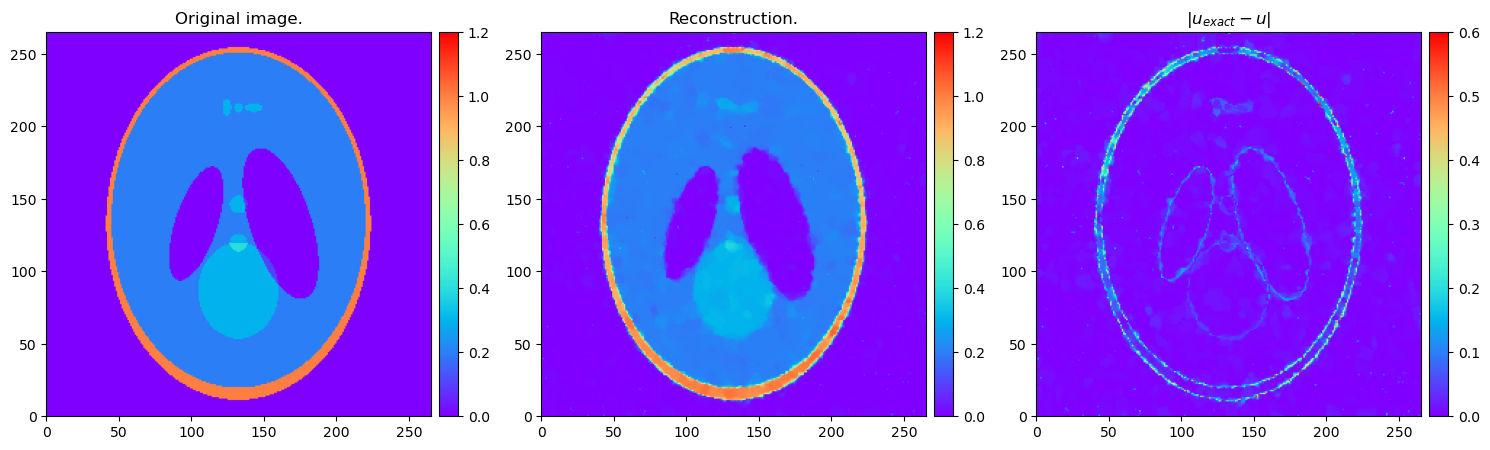

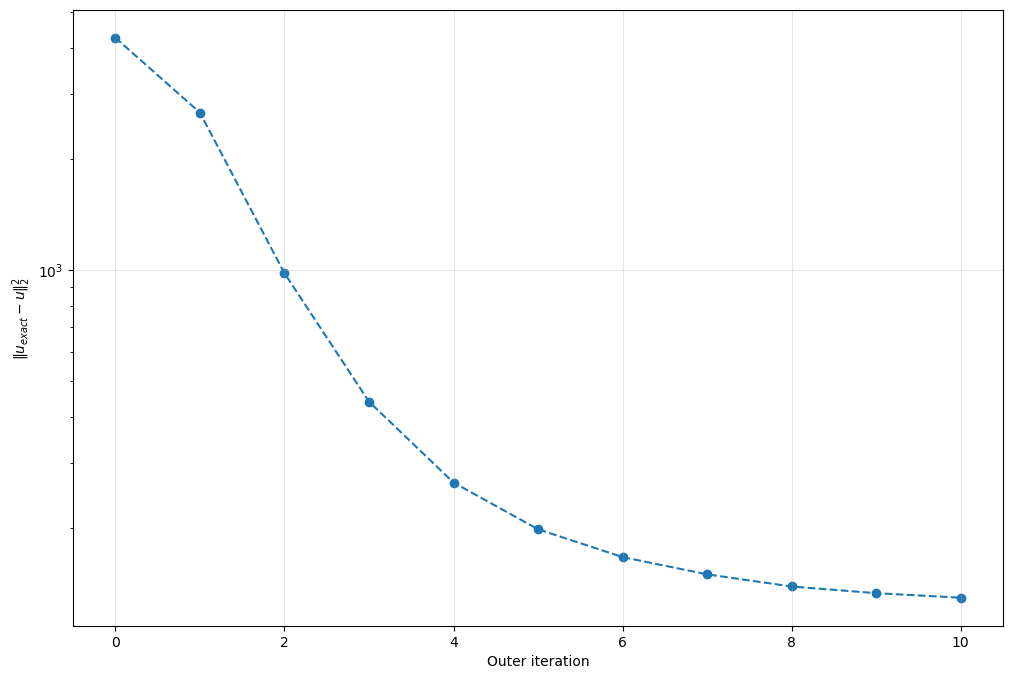

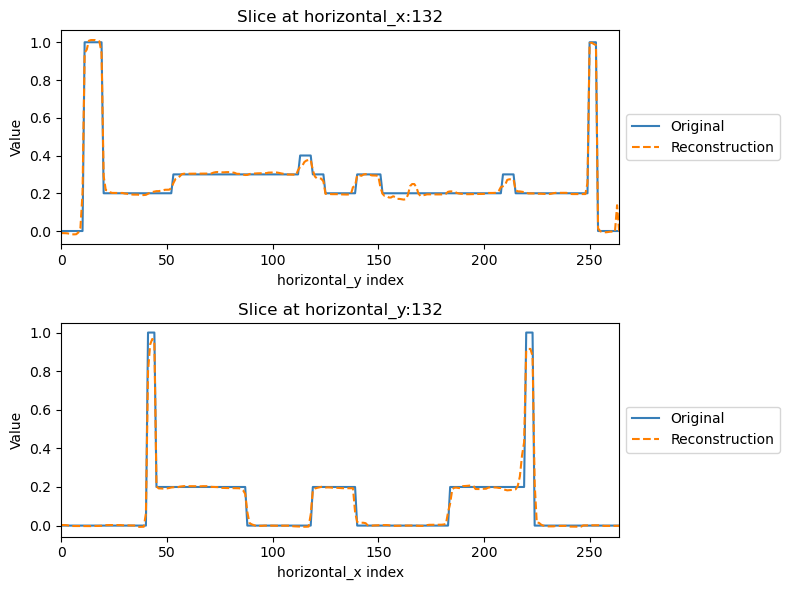

In [18]:
show2D([phantom, sol.abs(), (phantom-sol).abs()], ['Original image.', 'Reconstruction.', '$|u_{exact} - u|$'], 
       num_cols=3,
       cmap='rainbow', 
       axis_labels=('', ''), 
       fix_range= [(0,1.2), (0,1.2),(0,0.6)])
x = np.linspace(0,len(sol_err) - 1, len(sol_err))

plt.figure(figsize=(12,8))
plt.semilogy(x, sol_err, linestyle='--')
plt.ylabel('$\|u_{exact} - u\|_2^2$')
plt.xlabel('Outer iteration')
plt.scatter(x,sol_err)
plt.grid(alpha=0.3)

show1D([phantom, sol], dataset_labels=['Original', 'Reconstruction'])